In [27]:
import os

# Il percorso base dove Kaggle monta i dataset
dataset_path = '/kaggle/input'

In [28]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class MFNetDataset(Dataset):
    def __init__(self, base_path, transform=None):
        # 1. Abbiamo solo due cartelle vere!
        self.dir_immagini = os.path.join(base_path, "images")
        self.dir_maschere = os.path.join(base_path, "labels")
        
        # 2. Troviamo i file comuni
        nomi_immagini = {os.path.splitext(f)[0] for f in os.listdir(self.dir_immagini)}
        nomi_maschere = {os.path.splitext(f)[0] for f in os.listdir(self.dir_maschere)}
        
        self.nomi_comuni = sorted(list(nomi_immagini.intersection(nomi_maschere)))
        
        print(f"Dataset inizializzato: {len(self.nomi_comuni)} immagini a 4 canali trovate.")
        self.transform = transform

    def __len__(self):
        return len(self.nomi_comuni)

    def __getitem__(self, idx):
        nome_base = self.nomi_comuni[idx]
        
        path_immagine = os.path.join(self.dir_immagini, nome_base + ".png")
        path_maschera = os.path.join(self.dir_maschere, nome_base + ".png")
        
        # --- LA MAGIA DELLO SDOPPIAMENTO ---
        # Apriamo l'immagine grezza mantenendo tutti e 4 i canali
        img_rgba = Image.open(path_immagine)
        
        # Estraiamo l'Esperto RGB (i primi 3 canali)
        image_visual = img_rgba.convert('RGB')
        
        # Estraiamo l'Esperto Termico (Il canale 'A' nascosto)
        # Lo convertiamo in RGB (3 canali grigi identici) così la tua U-Net che si aspetta 3 canali non va in crash!
        image_termica = img_rgba.getchannel('A').convert('RGB')
        
        # -----------------------------------
        
        image_maschera = Image.open(path_maschera).convert('L') 
        mask_np = np.array(image_maschera)
        tensor_maschera = torch.as_tensor(mask_np, dtype=torch.long)

        # Applichiamo i tensori
        if self.transform:
            tensor_termica = self.transform(image_termica)
            tensor_visual = self.transform(image_visual)
        else:
            tensor_termica = image_termica
            tensor_visual = image_visual

        # ORDINE FISSO: Termica, Visual, Maschera
        return tensor_termica, tensor_visual, tensor_maschera

Dataset inizializzato: 1569 immagini a 4 canali trovate.


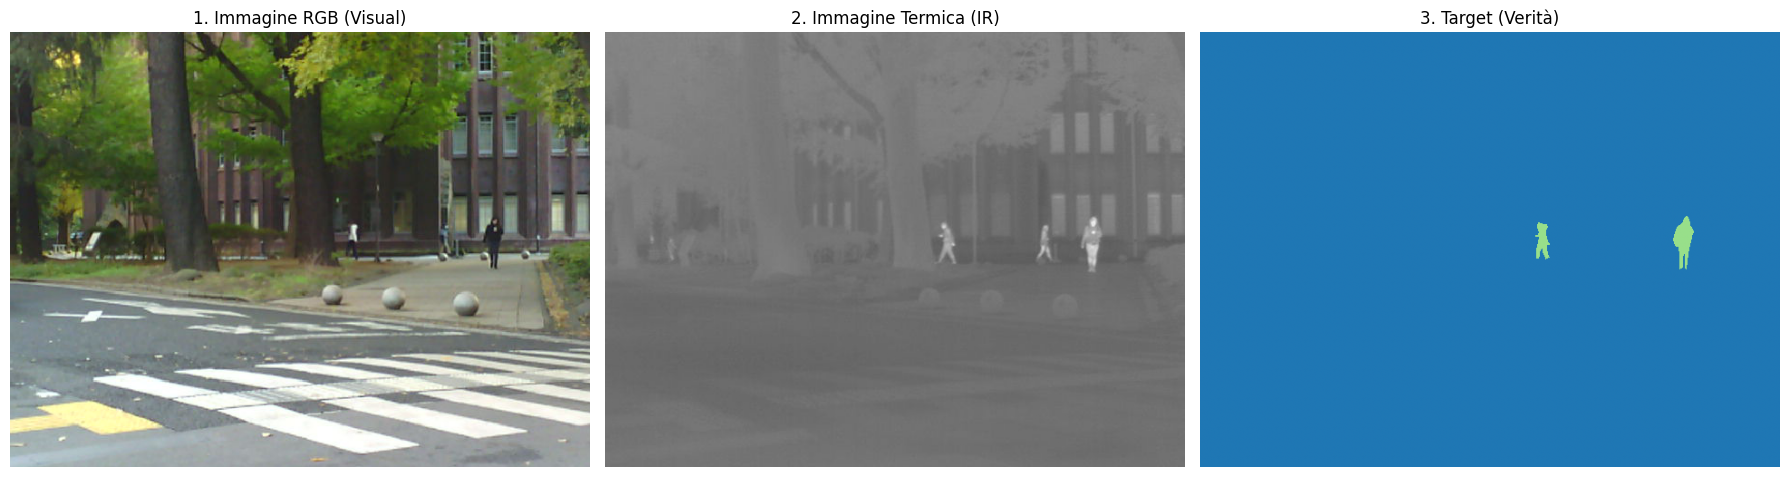

In [31]:
import matplotlib.pyplot as plt
import random
from torchvision import transforms

# 1. DISTRUGGIAMO IL VECCHIO DATASET E RICREAMOLO! (Questo è il passaggio che mancava)
mia_trasformazione = transforms.ToTensor()
dataset_training = MFNetDataset(
    base_path="/kaggle/input/datasets/danialqashqai/mfnet-dataset/MFNet-dataset/ir_seg_dataset", 
    transform=mia_trasformazione
)

# 2. Peschiamo un indice a caso dal NUOVO dataset
indice_casuale = random.randint(0, len(dataset_training) - 1)
img_termica, img_visual, maschera_vera = dataset_training[indice_casuale]

# 3. Prepariamo le immagini
img_t_plot = img_termica.permute(1, 2, 0).numpy()
img_v_plot = img_visual.permute(1, 2, 0).numpy() 
mask_v_plot = maschera_vera.numpy()

# --- 4. DISEGNIAMO IL CONFRONTO A 3 COLONNE ---
fig, assi = plt.subplots(1, 3, figsize=(18, 5))

# COLONNA 1: La foto a colori (I primi 3 canali)
assi[0].imshow(img_v_plot) 
assi[0].set_title("1. Immagine RGB (Visual)")
assi[0].axis('off')

# COLONNA 2: La VERA immagine termica (Il canale Nascosto)
assi[1].imshow(img_t_plot) 
assi[1].set_title("2. Immagine Termica (IR)")
assi[1].axis('off')

# COLONNA 3: La Maschera Target
assi[2].imshow(mask_v_plot, cmap='tab20', vmin=0, vmax=8)
assi[2].set_title("3. Target (Verità)")
assi[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

mia_trasformazione = transforms.ToTensor()

dataset_training = MFNetDataset(base_path="/kaggle/input/datasets/danialqashqai/mfnet-dataset/MFNet-dataset/ir_seg_dataset", transform=mia_trasformazione)

termica, maschera, visual = dataset_training[0]

print("Formato Termica:", type(termica), "- Dimensioni:", termica.shape)
print("Formato Maschera:", type(maschera), "- Dimensioni:", maschera.shape)
print("Formato visual:", type(visual), "- Dimensioni:", visual.shape)

In [2]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv_block(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(UNet, self).__init__()
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        
        self.bottleneck = DoubleConv(512, 1024)

    # IL DECODER
        
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)
        
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)
        
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)
        
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)
        

    def forward(self, x):
        # --- 1. L'ENCODER (La discesa) ---
        x1 = self.down1(x)
        p1 = self.pool(x1)
        
        x2 = self.down2(p1)
        p2 = self.pool(x2)
        
        x3 = self.down3(p2)
        p3 = self.pool(x3)
        
        x4 = self.down4(p3)
        p4 = self.pool(x4)
        
        # --- 2. IL BOTTLENECK (Il fondo) ---
        b = self.bottleneck(p4)
        
        # --- 3. IL DECODER (La salita) ---
        
        # Step 1 di risalita
        u1 = self.up1(b)                             # Ingrandiamo il bottleneck
        concat1 = torch.cat([x4, u1], dim=1)         # Uniamo la skip connection (x4) con l'immagine ingrandita (u1)
        d1 = self.up_conv1(concat1)                  # Passiamo tutto nel DoubleConv
        
        # Step 2 di risalita
        u2 = self.up2(d1)
        concat2 = torch.cat([x3, u2], dim=1)
        d2 = self.up_conv2(concat2)
        
        # Step 3 di risalita (Tocca a te!)
        u3 = self.up3(d2)
        concat3 = torch.cat([x2, u3], dim=1)
        d3 = self.up_conv3(concat3)
        
        # Step 4 di risalita (Tocca a te!)
        u4 = self.up4(d3)
        concat4 = torch.cat([x1, u4], dim=1)
        d4 = self.up_conv4(concat4)
        
        # --- 4. OUTPUT FINALE ---
        out = self.final_conv(d4)
        
        return out

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


# Diciamo a PyTorch di usare la GPU se disponibile, altrimenti la CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sto usando: {device}")

# Creiamo il modello e lo spediamo sulla GPU
modello = UNet(in_channels=3, num_classes=9).to(device)
if torch.cuda.device_count() > 1:
    print(f"Sto usando {torch.cuda.device_count()} GPU!")
    modello = nn.DataParallel(modello)

# Il DataLoader raggruppa le immagini (es. 4 alla volta) e le mischia (shuffle)
dataloader = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

pesi = torch.tensor([0.1, 1.5, 2.0, 2.0, 1.0, 1.0, 1.0, 1.5, 1.5]).to(device)
criterio = nn.CrossEntropyLoss(weight=pesi)
# L'Ottimizzatore (Adam è il più famoso e stabile, lr è il 'Learning Rate' ovvero la velocità di apprendimento)
ottimizzatore = optim.Adam(modello.parameters(), lr=0.0001)


# --- 2. IL CICLO DI ADDESTRAMENTO ---

epoche = 15 # Quante volte guardiamo TUTTO il dataset
for epoca in range(epoche):
    modello.train() # Mette il modello in modalità "studente"
    
    # enumerate ci permette di avere il numero del batch (batch_idx) e i dati
    for batch_idx, (termica, visual, maschera) in enumerate(dataloader):
    
        # Spostiamo tutto sulla GPU
        termica = termica.to(device)
        visual = visual.to(device)
        maschera = maschera.to(device)
        
        # --- PROGETTO 1: Alleniamo sul TERMICO ---
        # Passiamo 'termica' al modello
        predizioni = modello(termica) 
        
        # Calcoliamo la loss usando la 'maschera' (quella vera!)
        loss = criterio(predizioni, maschera)
        
        # Step 3: Azzera i gradienti 
        ottimizzatore.zero_grad()
        
        # Step 4: Backward (Usa il metodo .backward() sulla tua 'loss')
        loss.backward()
        
        # Step 5: Aggiorna i pesi (Usa il metodo .step() sul tuo 'ottimizzatore')
        ottimizzatore.step()
        
        if batch_idx % 10 == 0:
            print(f"Epoca [{epoca+1}/{epoche}] - Batch {batch_idx} - Loss: {loss.item():.4f}")

Sto usando: cuda
Sto usando 2 GPU!
Epoca [1/15] - Batch 0 - Loss: 2.0791
Epoca [1/15] - Batch 10 - Loss: 1.9175
Epoca [1/15] - Batch 20 - Loss: 1.6284
Epoca [1/15] - Batch 30 - Loss: 1.9497
Epoca [1/15] - Batch 40 - Loss: 1.9130
Epoca [1/15] - Batch 50 - Loss: 1.9275
Epoca [1/15] - Batch 60 - Loss: 1.5109
Epoca [1/15] - Batch 70 - Loss: 1.8697
Epoca [1/15] - Batch 80 - Loss: 1.7000
Epoca [1/15] - Batch 90 - Loss: 1.6152
Epoca [1/15] - Batch 100 - Loss: 1.6946
Epoca [1/15] - Batch 110 - Loss: 2.0103
Epoca [1/15] - Batch 120 - Loss: 1.7818
Epoca [1/15] - Batch 130 - Loss: 1.8170
Epoca [1/15] - Batch 140 - Loss: 1.8101
Epoca [1/15] - Batch 150 - Loss: 1.4106
Epoca [1/15] - Batch 160 - Loss: 1.5651
Epoca [1/15] - Batch 170 - Loss: 1.8086
Epoca [1/15] - Batch 180 - Loss: 1.1786
Epoca [1/15] - Batch 190 - Loss: 1.4601
Epoca [1/15] - Batch 200 - Loss: 1.7144
Epoca [1/15] - Batch 210 - Loss: 1.4544
Epoca [1/15] - Batch 220 - Loss: 1.5533
Epoca [1/15] - Batch 230 - Loss: 1.8357
Epoca [1/15] - B

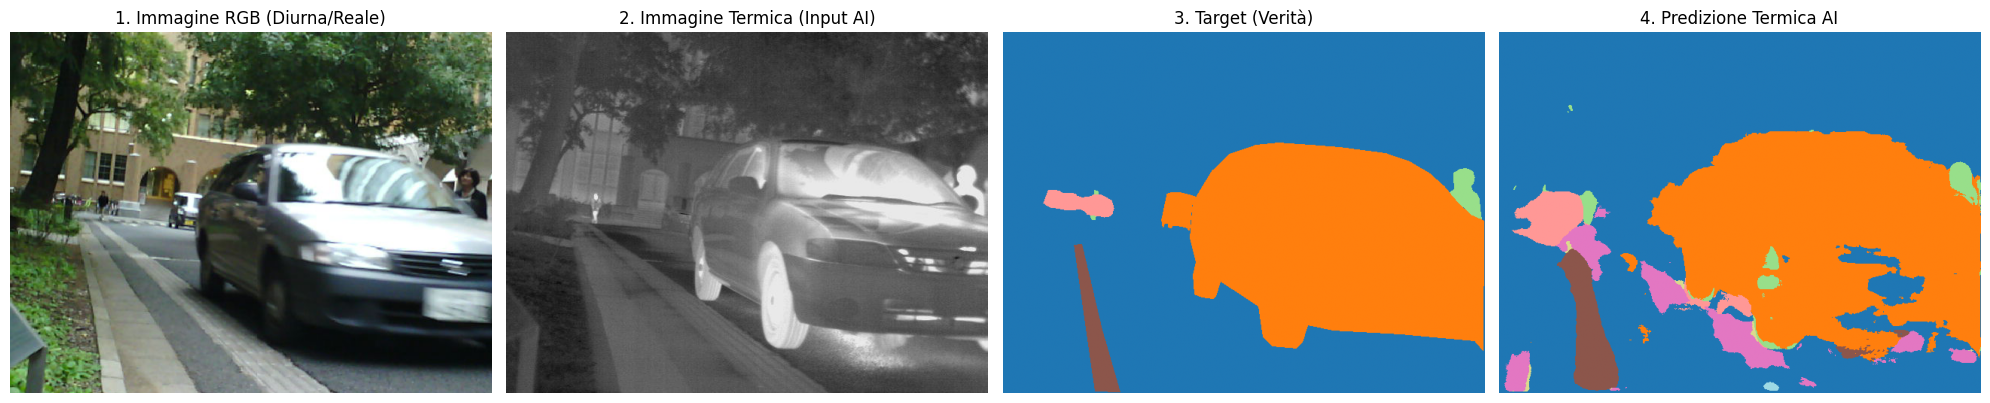

🔍 LEGENDA RAPIDA (Se vedi questi colori nella Predizione):
- Viola/Blu Scuro: Sfondo (Asfalto, Cielo)
- Arancione: Auto (Car)
- Verde Chiaro: Pedone (Person)


In [37]:
import matplotlib.pyplot as plt
import torch
import random
import numpy as np

# 1. Modalità Valutazione
modello.eval()

# 2. Peschiamo un indice a caso - L'ordine ora è corretto col tuo Dataset
indice_casuale = random.randint(0, len(dataset_training) - 1)
img_termica, img_visual, maschera_vera = dataset_training[indice_casuale]

# 3. Prepariamo l'input per il modello (L'Esperto Termico guarda la TERMICA)
img_input = img_termica.unsqueeze(0).to(device)

# 4. Inferenza
with torch.no_grad():
    output = modello(img_input)
    predizione = torch.argmax(output, dim=1).squeeze(0)

# 5. Prepariamo le immagini per Matplotlib (da Tensore a Numpy HxWxC)
img_t_plot = img_termica.permute(1, 2, 0).cpu().numpy()
img_v_plot = img_visual.permute(1, 2, 0).cpu().numpy() 
mask_v_plot = maschera_vera.cpu().numpy()
pred_plot = predizione.cpu().numpy()

# --- 6. DISEGNIAMO IL CONFRONTO A 4 COLONNE (FINALMENTE GIUSTO) ---
fig, assi = plt.subplots(1, 4, figsize=(20, 5))

# COLONNA 1: Immagine Visuale (RGB) - Usiamo img_v_plot
assi[0].imshow(img_v_plot) 
assi[0].set_title("1. Immagine RGB (Diurna/Reale)")
assi[0].axis('off')

# COLONNA 2: Immagine Termica - Usiamo img_t_plot
assi[1].imshow(img_t_plot) 
assi[1].set_title("2. Immagine Termica (Input AI)")
assi[1].axis('off')

# COLONNA 3: Maschera Reale (Target)
assi[2].imshow(mask_v_plot, cmap='tab20', vmin=0, vmax=8)
assi[2].set_title("3. Target (Verità)")
assi[2].axis('off')

# COLONNA 4: Predizione dell'AI
assi[3].imshow(pred_plot, cmap='tab20', vmin=0, vmax=8)
assi[3].set_title(f"4. Predizione Termica AI")
assi[3].axis('off')

plt.tight_layout()
plt.show()

# --- EXTRA: PICCOLA LEGENDA PER NON IMPAZZIRE CON I COLORI ---
print("🔍 LEGENDA RAPIDA (Se vedi questi colori nella Predizione):")
print("- Viola/Blu Scuro: Sfondo (Asfalto, Cielo)")
print("- Arancione: Auto (Car)")
print("- Verde Chiaro: Pedone (Person)")

In [39]:
torch.save(modello.state_dict(), "best_ir.pth")

In [ ]:
from PIL import Image
import numpy as np
import os

# Peschiamo la prima immagine dalla cartella
cartella_immagini = "/kaggle/input/datasets/danialqashqai/mfnet-dataset/MFNet-dataset/ir_seg_dataset/images"
prima_immagine = os.listdir(cartella_immagini)[0]
path_test = os.path.join(cartella_immagini, prima_immagine)

# Apriamola SENZA conversioni
img_raw = Image.open(path_test)
array_raw = np.array(img_raw)

print(f"File analizzato: {prima_immagine}")
print(f"Modo originale dell'immagine: {img_raw.mode}")
print(f"Dimensioni grezze: {array_raw.shape}")

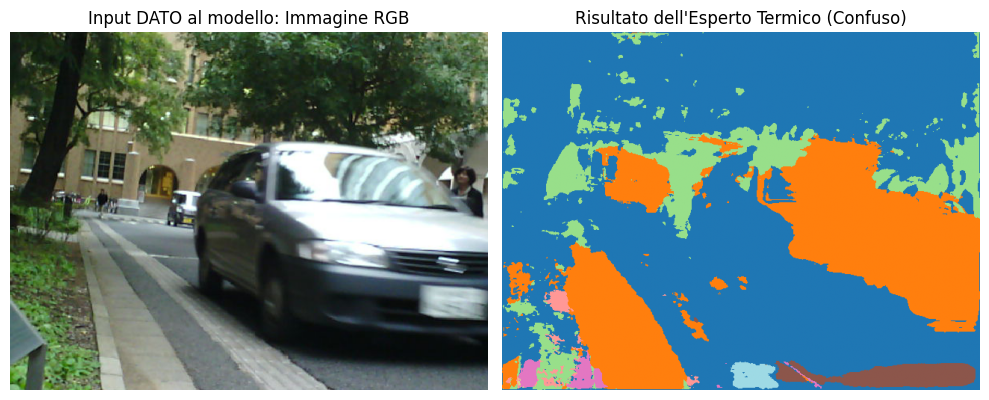

In [41]:
# --- LA PROVA DEL 10: INGANNIAMO IL MODELLO ---

# 1. Prendiamo la foto RGB (Diurna/Reale) e la passiamo al modello TERMICO
img_inganno = img_visua.unsqueeze(0).to(device) # <-- NOTA: Stiamo passando img_visual!

modello.eval()
with torch.no_grad():
    output_inganno = modello(img_inganno)
    pred_inganno = torch.argmax(output_inganno, dim=1).squeeze(0).cpu().numpy()

# 2. Disegniamo il risultato
fig, assi = plt.subplots(1, 2, figsize=(10, 5))

assi[0].imshow(img_v_plot) 
assi[0].set_title("Input DATO al modello: Immagine RGB")
assi[0].axis('off')

assi[1].imshow(pred_inganno, cmap='tab20', vmin=0, vmax=8)
assi[1].set_title("Risultato dell'Esperto Termico (Confuso)")
assi[1].axis('off')

plt.tight_layout()
plt.show()